# Line Delay Rankings

Ranks lines separately by late-only and early-only delay.

In [1]:
from pathlib import Path
import importlib.util
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "analysis"))

spec = importlib.util.spec_from_file_location(
    "line_delay_rankings",
    PROJECT_ROOT / "analysis" / "line-delay-rankings.py",
)
rankings = importlib.util.module_from_spec(spec)
spec.loader.exec_module(rankings)

DB = PROJECT_ROOT / "data" / "foli.db"
MIN_OBSERVATIONS = 50
LIMIT = 10
TIMEZONE = "Europe/Helsinki"
QUALITY_MODE = "conservative"
BUCKET = "trip-stop"

In [2]:
class Args:
    db = DB
    timezone = TIMEZONE
    quality_mode = QUALITY_MODE
    exclude_stop_call_disagreement = False
    bucket = BUCKET

df = rankings.load_observations(Args)
buckets = rankings.prepare_buckets(Args, df)
late = rankings.rank_late(buckets, MIN_OBSERVATIONS, LIMIT)
early = rankings.rank_early(buckets, MIN_OBSERVATIONS, LIMIT)
late

,line_ref,line_name,bucket_count,raw_poll_count,signed_mean_delay_min,median_delay_min,p75_delay_min,p90_delay_min,p95_delay_min,pct_over_3_min_late,pct_over_5_min_late
51,612,612,1397,3049,4.94,4.12,9.95,15.38,17.52,52.97,46.96
53,615,615,3199,6168,4.39,2.80,9.26,14.79,17.29,48.77,37.95
109,L8,L8,50,1544,3.51,3.66,6.44,11.38,13.53,54.00,36.00
52,614,614,3393,7517,4.43,4.00,6.72,10.23,12.41,59.65,39.91
70,720,720,1601,3357,3.14,3.12,5.58,8.45,9.77,51.28,29.42
14,25,25,13306,25095,2.82,2.06,5.15,8.37,10.85,41.61,26.01
132,V1,V1,2345,7173,2.13,1.45,4.62,8.31,9.37,35.35,22.26
35,42A,42A,1899,4846,2.00,0.87,3.17,8.17,10.17,26.59,18.96
13,24,24,24585,47758,2.35,1.03,4.17,8.07,11.13,32.44,20.39
15,25A,25A,15796,29511,3.40,2.72,4.90,7.95,10.35,45.97,24.19


In [3]:
early

,line_ref,line_name,bucket_count,raw_poll_count,signed_mean_delay_min,median_delay_min,pct_early,pct_over_1_min_early,pct_over_3_min_early,median_early_min_abs,p90_early_min_abs
129,P6,P6,1663,5482,-6.62,-4.23,93.81,83.88,60.85,4.95,16.12
90,903,903,995,3579,0.08,0.00,30.75,24.32,12.66,2.32,12.85
89,901,901,8076,28413,-2.55,0.00,49.24,37.36,24.26,2.92,12.02
53,615,615,3199,6168,4.39,2.80,24.66,18.19,10.03,2.39,9.47
112,N10,N10,1189,5271,-2.69,-2.57,70.14,62.66,46.43,4.70,8.88
84,801,801,45201,104803,-0.52,0.00,48.25,35.30,19.39,2.22,8.57
77,75,75,283,1018,-3.81,-2.55,93.29,85.51,46.64,3.00,8.45
105,L4,L4,1445,5292,-1.92,-1.57,62.84,54.46,34.46,3.53,8.05
121,N7,N7,1593,8216,-1.39,-0.32,53.86,44.70,31.64,3.62,7.96
34,42,42,1722,4739,1.49,0.82,34.67,19.74,8.94,1.42,7.91


Text(0, 0.5, 'Line')

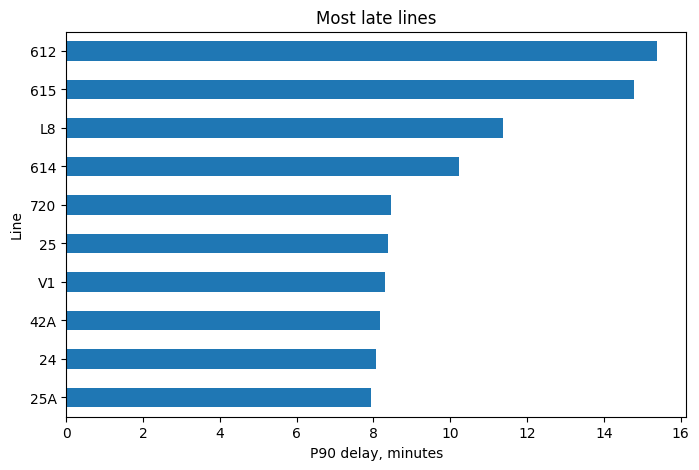

In [4]:
ax = late.sort_values("p90_delay_min").plot.barh(
    x="line_ref",
    y="p90_delay_min",
    legend=False,
    figsize=(8, 5),
    title="Most late lines",
)
ax.set_xlabel("P90 delay, minutes")
ax.set_ylabel("Line")